Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Método de Ritz en una membrana

## Problema a resolver

Tenemos el siguiente funcional

$$J[u] = \int\limits_{0}^{1}\int\limits_{0}^{1}[u_x^2 + u_y^2 + 2uf]\, \mathrm{d}x\, \mathrm{d}y\, ,$$

que también puede escribirse como

$$J[u] = \int\limits_{0}^{1}\int\limits_{0}^{1}[\nabla u \cdot \nabla u + 2uf]\, \mathrm{d}x\, \mathrm{d}y\, .$$

El problema de minimización

$$\min_{u \in V} J[u]\, ,$$

con $u = 0$ en la frontera, es equivalente a

$$\nabla^2 u = f  \quad \forall (x,y) \in [0, 1]^2$$

con $u = 0$ en la frontera.


Para el caso

$$f(x, y) = -2\pi \sin(\pi x)\sin(\pi y)\, ,$$

la solución analítica está dada por

$$u_e(x, y) = \sin(\pi x)\sin(\pi y)\, ,$$

## Aproximación propuesta

Propongamos una aproximación a la solución de la siguiente forma

$$u_N(x) = \sum_{i=0}^N c_i \phi_i(x, y) = x y (1-x) (y - 1)\left[c_0
+  c_1 x + c_2 y + c_3 x^2 + c_4 xy + c_5 y^2 + \cdots \right]\, ,$$

en donde vemos que esta función satisface las condiciones de frontera.


In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
from sympy import *
from sympy.plotting import plot3d

In [4]:
init_session()

IPython console for SymPy 1.14.0 (Python 3.14.4-64-bit) (ground types: gmpy)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.14.0/



In [5]:
def poli_completo(x, y, n):
    """
    Devuelve la base monomial para el polinomio
    completo en x e y de orden n.

    Parámetros
    ----------
    x : símbolo de SymPy.
        Variable del polinomio.
    y : símbolo de SymPy.
        Variable del polinomio.
    n : int
        Orden del polinomio.

    Retorna
    -------
    w : list
        Elementos de la base monomial
        para el polinomio en x e y.
    c : tuple
        Coeficientes para la base
    """
    nfun = (n + 1) * (n + 2) // 2 # n-ésimo número triangular
    c = symbols('c:%d' % (nfun))
    w = []
    for i in range(0, n + 1):
        for j in range(0, i + 1):
            w.append(x**(i - j) * y**j)
    return w, c

def b(x, y):
    """Condicones de frontera"""
    return x * y * (1 - x) * (1 - y)


def phi(x, y, n):
    """ Funciones base con condiciones de frontera """
    w, c = poli_completo(x, y, n)
    return [b(x, y) * phi for phi in w], c


def u_fun(x, y, n):
    """ Funciones base con condiciones de frontera """
    u = 0*x
    w, c = phi(x, y, n)
    nfun = (n + 1) * (n + 2) // 2
    # for cont in range(nfun):
    #     u += c[cont] * w[cont]
    for ci, wi in zip(c, w):
        u += ci * wi
    
    return u, c


In [6]:
u_e = sin(pi*x)*sin(pi*y)
u_e

In [7]:
f = -2*pi**2*sin(pi*x)*sin(pi*y)
f

In [8]:
u, c = u_fun(x, y, 0)
u

In [9]:
dens_ener = (u.diff(x))**2 + (u.diff(y))**2 + 2*u*f
dens_ener

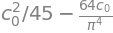

In [10]:
ener = integrate(dens_ener, (x, 0, 1), (y, 0, 1))
ener

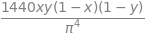

In [11]:
eqs = Matrix([ener]).jacobian(c)
u.subs(solve(eqs, c))

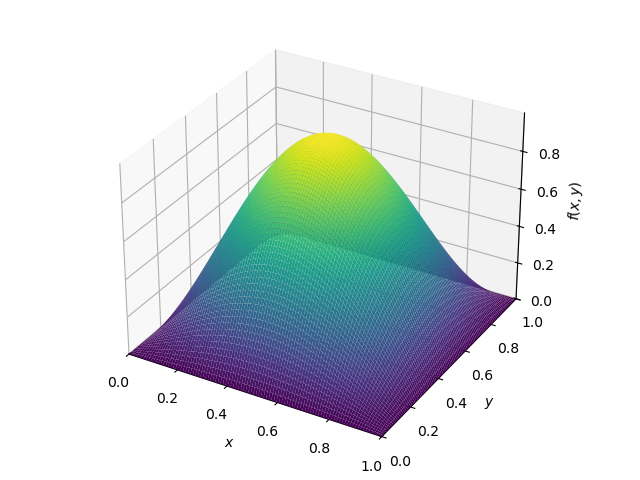

In [12]:
plot3d(u_e, (x, 0, 1), (y, 0, 1))

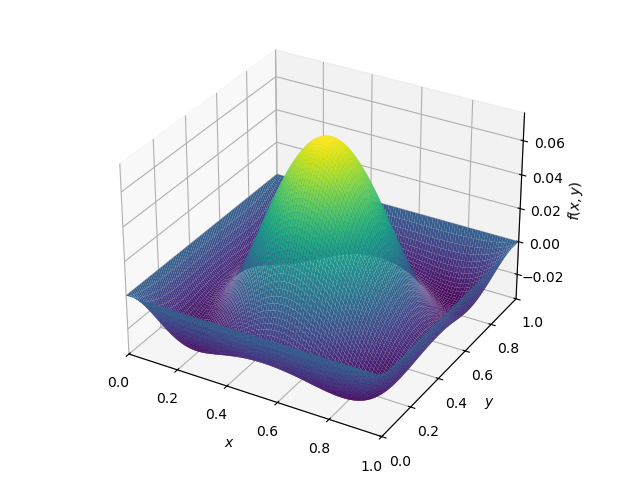

In [13]:
plot3d(u_e - u.subs(solve(eqs, c)), (x, 0, 1), (y, 0, 1))